# Information Theory Measures for Hyperscanning

Authors: Rémy Ramadour, Guillaume Dumas

Date: 2026-01-06

This notebook demonstrates the use of **Mutual Information (MI)** and **Transfer Entropy (TE)** for hyperscanning EEG analysis using HyPyP.

In this notebook we:
- **Load libraries** for core operations, data science, visualization, and EEG analysis (using MNE).
- **Load and preprocess data** (ICA correction and autoreject) for two participants.
- **Compute Mutual Information** (symmetric measure of information sharing).
- **Compute Transfer Entropy** (directional measure of information flow).
- **Compare MI/TE with traditional metrics** (PLV, coherence).
- **Visualize** inter-brain connectivity using HyPyP's visualization functions.

The expected outputs are cleaned EEG epochs, MI and TE matrices, and visualizations that help interpret information-theoretic inter-brain connectivity.

## Load useful libs

### Core

In [19]:
import io
from copy import copy
from collections import OrderedDict
import requests
import tempfile  # For creating temporary files

### Data science

In [20]:
import numpy as np
import scipy

### Visualization

In [21]:
import matplotlib.pyplot as plt

### MNE

In [22]:
import mne

### HyPyP

In [23]:
from hypyp import prep
from hypyp import analyses
from hypyp import analyses_it
from hypyp import stats
from hypyp import viz

## Setting Analysis Parameters

We define the frequency bands used for comparison with traditional metrics. We use Alpha band to compare with MI/TE results.

In [24]:
# Define frequency bands as a dictionary
freq_bands = {
    'Alpha': [8, 13]
}

# Convert to an OrderedDict to keep the defined order
freq_bands = OrderedDict(freq_bands)
print('Frequency bands:', freq_bands)

Frequency bands: OrderedDict({'Alpha': [8, 13]})


## Loading Data

In this section we download the EEG datasets for two participants, convert them to MNE Epochs, and equalize the number of epochs across participants.

The function `get_data` downloads a dataset from a given URL and saves it to a temporary file with an MNE-compatible filename.

In [25]:
# Template URL for downloading participant data
URL_TEMPLATE = "https://github.com/ppsp-team/HyPyP/blob/master/data/participant{}-epo.fif?raw=true"

def get_data(idx):
    """
    Download EEG data for a given participant index and save it to a temporary file.
    
    Parameters:
        idx (int): Participant index number.
    
    Returns:
        str: File path of the temporary file containing the EEG data.
    """
    
    # Format the URL with the participant index
    url = URL_TEMPLATE.format(idx)
    
    # Download the data
    response = requests.get(url)
    
    # Save the content to a temporary file with the suffix '-epo.fif'
    temp_file = tempfile.NamedTemporaryFile(delete=False, suffix="-epo.fif")
    temp_file.write(response.content)
    temp_file.close()
    
    return temp_file.name

# Load epochs for two participants using MNE
epo1 = mne.read_epochs(
    get_data(1),
    preload=True,
) 

epo2 = mne.read_epochs(
    get_data(2),
    preload=True,
)

Reading /var/folders/tw/x1b5ldls1_s1t0h65sy4nsym0000gp/T/tmpigtafep1-epo.fif ...
    Found the data of interest:
        t =    -500.00 ...     500.00 ms
        0 CTF compensation matrices available
Not setting metadata
260 matching events found
No baseline correction applied
0 projection items activated
Reading /var/folders/tw/x1b5ldls1_s1t0h65sy4nsym0000gp/T/tmp2gmvwypv-epo.fif ...
    Found the data of interest:
        t =    -500.00 ...     500.00 ms
        0 CTF compensation matrices available
Not setting metadata
36 matching events found
No baseline correction applied
0 projection items activated


Since our example dataset was not initially dedicated to hyperscanning, we need to equalize the number of epochs between our two participants.

In [26]:
# Equalize the number of epochs between participants
mne.epochs.equalize_epoch_counts([epo1, epo2])

# Define sampling frequency from the first participant's data
sampling_rate = epo1.info['sfreq']
print('Sampling rate:', sampling_rate)
print('Number of epochs:', len(epo1))
print('Number of channels:', len(epo1.info['ch_names']))

Dropped 224 epochs: 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 56, 57, 58, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 100, 101, 104, 105, 106, 107, 108, 109, 110, 111, 113, 114, 116, 117, 118, 119, 120, 121, 122, 125, 126, 127, 128, 130, 131, 134, 135, 136, 137, 138, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 169, 172, 173, 175, 176, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 219, 220, 221, 222, 223, 225, 226, 227, 228, 229, 230, 231, 232, 233, 234, 235, 236, 237, 238, 239, 240, 243, 244, 245, 246, 247, 248, 249, 250, 251, 25

## Preprocessing Epochs

### ICA Correction

We perform Independent Component Analysis (ICA) on the data from both participants to identify and remove artefactual components.

Estimating rejection dictionary for eeg
The rejection dictionary is {'eeg': np.float64(0.00010129807784293706)}
0 bad epochs dropped
Fitting ICA to data using 31 channels (please be patient, this may take a while)
Selecting by number: 15 components
Computing Extended Infomax ICA
Fitting ICA took 0.9s.
Estimating rejection dictionary for eeg
The rejection dictionary is {'eeg': np.float64(4.747409473367548e-05)}
    Rejecting  epoch based on EEG : ['Fp1', 'F7', 'FT10', 'T8', 'TP10']
    Rejecting  epoch based on EEG : ['Fp1', 'FT10', 'TP10', 'O1']
    Rejecting  epoch based on EEG : ['Fp1', 'FT10']
    Rejecting  epoch based on EEG : ['O1']
4 bad epochs dropped
Fitting ICA to data using 31 channels (please be patient, this may take a while)
Selecting by number: 15 components
Computing Extended Infomax ICA


/Users/remyramadour/Library/Caches/pypoetry/virtualenvs/hypyp-MsYcTlun-py3.13/lib/python3.13/site-packages/scipy/linalg/_basic.py:1622: RuntimeWarning: divide by zero encountered in matmul
  B = (u @ vh[:rank]).conj().T
/Users/remyramadour/Library/Caches/pypoetry/virtualenvs/hypyp-MsYcTlun-py3.13/lib/python3.13/site-packages/scipy/linalg/_basic.py:1622: RuntimeWarning: overflow encountered in matmul
  B = (u @ vh[:rank]).conj().T
/Users/remyramadour/Library/Caches/pypoetry/virtualenvs/hypyp-MsYcTlun-py3.13/lib/python3.13/site-packages/scipy/linalg/_basic.py:1622: RuntimeWarning: invalid value encountered in matmul
  B = (u @ vh[:rank]).conj().T


Fitting ICA took 1.0s.


/Users/remyramadour/Library/Caches/pypoetry/virtualenvs/hypyp-MsYcTlun-py3.13/lib/python3.13/site-packages/scipy/linalg/_basic.py:1622: RuntimeWarning: divide by zero encountered in matmul
  B = (u @ vh[:rank]).conj().T
/Users/remyramadour/Library/Caches/pypoetry/virtualenvs/hypyp-MsYcTlun-py3.13/lib/python3.13/site-packages/scipy/linalg/_basic.py:1622: RuntimeWarning: overflow encountered in matmul
  B = (u @ vh[:rank]).conj().T
/Users/remyramadour/Library/Caches/pypoetry/virtualenvs/hypyp-MsYcTlun-py3.13/lib/python3.13/site-packages/scipy/linalg/_basic.py:1622: RuntimeWarning: invalid value encountered in matmul
  B = (u @ vh[:rank]).conj().T


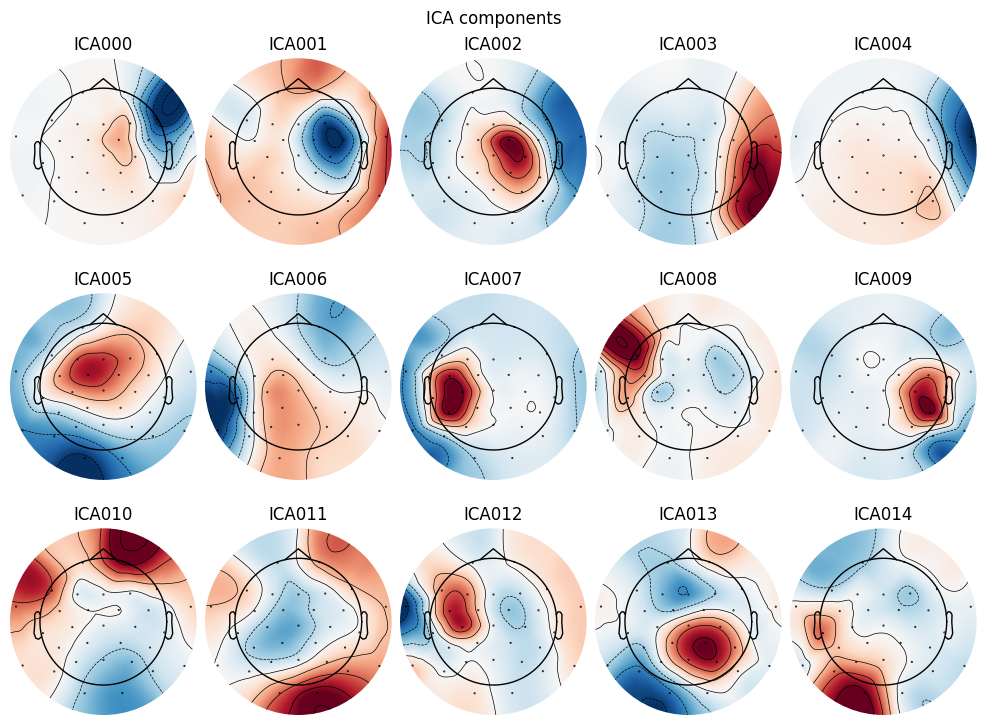

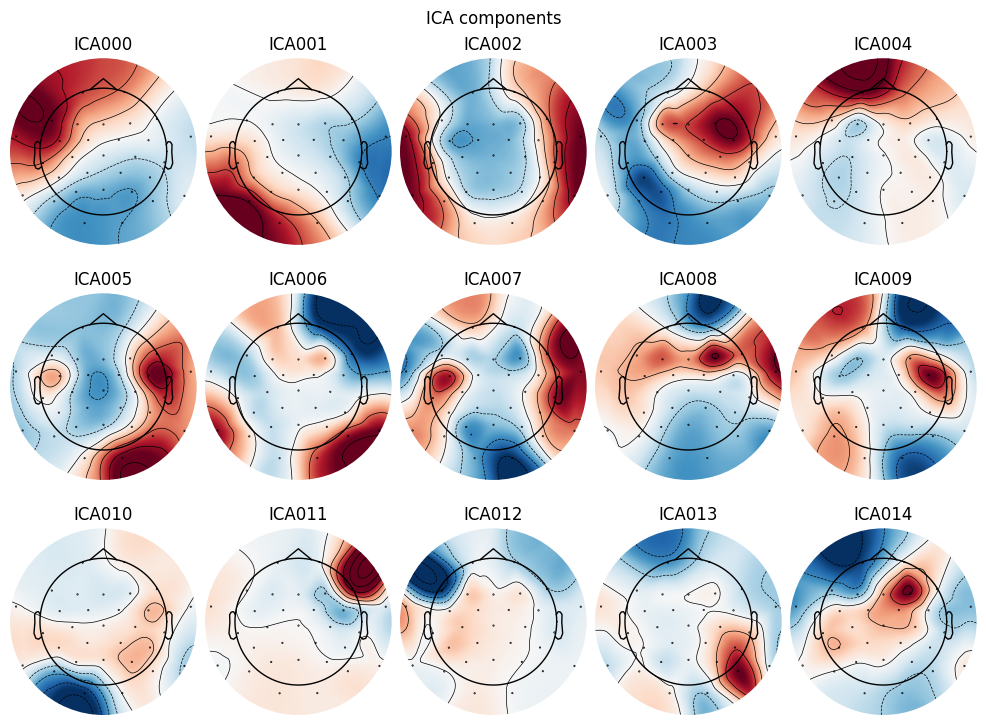

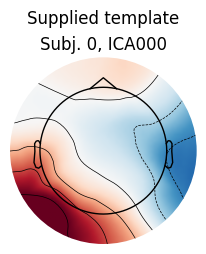

Median correlation with constructed map: 1.000
Displaying selected ICs per subject.
No maps selected for subject [0], consider a more liberal threshold.


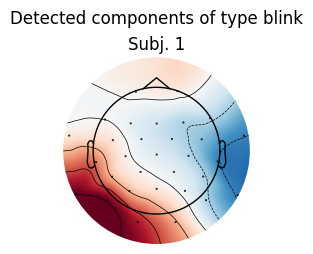

[{'blink': []}, {'blink': [np.int64(1)]}]
Applying ICA to Epochs instance
    Transforming to ICA space (15 components)
    Zeroing out 0 ICA components
    Projecting back using 31 PCA components
Applying ICA to Epochs instance
    Transforming to ICA space (15 components)
    Zeroing out 1 ICA component
    Projecting back using 31 PCA components
ICA correction completed.


/Users/remyramadour/Library/Caches/pypoetry/virtualenvs/hypyp-MsYcTlun-py3.13/lib/python3.13/site-packages/mne/preprocessing/ica.py:2372: RuntimeWarning: divide by zero encountered in matmul
  mixing = pca_components.T @ mixing
/Users/remyramadour/Library/Caches/pypoetry/virtualenvs/hypyp-MsYcTlun-py3.13/lib/python3.13/site-packages/mne/preprocessing/ica.py:2372: RuntimeWarning: overflow encountered in matmul
  mixing = pca_components.T @ mixing
/Users/remyramadour/Library/Caches/pypoetry/virtualenvs/hypyp-MsYcTlun-py3.13/lib/python3.13/site-packages/mne/preprocessing/ica.py:2372: RuntimeWarning: invalid value encountered in matmul
  mixing = pca_components.T @ mixing


In [27]:
# Compute ICA for each participant with 15 components
icas = prep.ICA_fit([
    epo1, epo2
],
    n_components=15,
    method='infomax',
    fit_params=dict(extended=True),
    random_state=42
)

# Select the relevant independent components for artefact rejection
cleaned_epochs_ICA = prep.ICA_choice_comp(icas, [epo1, epo2])
print('ICA correction completed.')

### Autoreject

In this cell, we apply the local AutoReject algorithm using HyPyP. This step automatically rejects or interpolates bad epochs/channels while ensuring that the same channels/epochs are removed across participants.

Running autoreject on ch_type=eeg


  0%|          | Creating augmented epochs : 0/31 [00:00<?,       ?it/s]

/Users/remyramadour/Library/Caches/pypoetry/virtualenvs/hypyp-MsYcTlun-py3.13/lib/python3.13/site-packages/scipy/linalg/_basic.py:1622: RuntimeWarning: divide by zero encountered in matmul
  B = (u @ vh[:rank]).conj().T
/Users/remyramadour/Library/Caches/pypoetry/virtualenvs/hypyp-MsYcTlun-py3.13/lib/python3.13/site-packages/scipy/linalg/_basic.py:1622: RuntimeWarning: overflow encountered in matmul
  B = (u @ vh[:rank]).conj().T
/Users/remyramadour/Library/Caches/pypoetry/virtualenvs/hypyp-MsYcTlun-py3.13/lib/python3.13/site-packages/scipy/linalg/_basic.py:1622: RuntimeWarning: invalid value encountered in matmul
  B = (u @ vh[:rank]).conj().T
/Users/remyramadour/Library/Caches/pypoetry/virtualenvs/hypyp-MsYcTlun-py3.13/lib/python3.13/site-packages/mne/channels/interpolation.py:130: RuntimeWarning: divide by zero encountered in matmul
  inst._data[..., bads_idx, :] = np.matmul(
/Users/remyramadour/Library/Caches/pypoetry/virtualenvs/hypyp-MsYcTlun-py3.13/lib/python3.13/site-packages/m

  0%|          | Computing thresholds ... : 0/31 [00:00<?,       ?it/s]

  0%|          | Repairing epochs : 0/36 [00:00<?,       ?it/s]

...





Estimated consensus=0.30 and n_interpolate=4
Dropped 8 epochs: 0, 1, 3, 4, 5, 6, 9, 20


  0%|          | Repairing epochs : 0/28 [00:00<?,       ?it/s]

No bad epochs were found for your data. Returning a copy of the data you wanted to clean. Interpolation may have been done.
Dropped 8 epochs: 0, 1, 3, 4, 5, 6, 9, 20


  0%|          | Repairing epochs : 0/28 [00:00<?,       ?it/s]

No bad epochs were found for your data. Returning a copy of the data you wanted to clean. Interpolation may have been done.
22.22222222222222 percent of bad epochs
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).


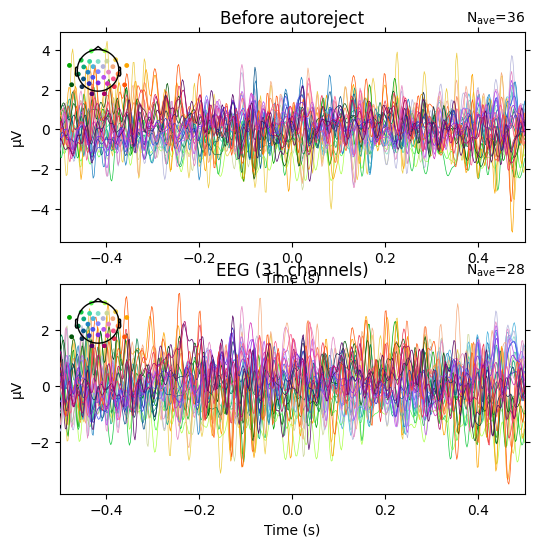

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).


<Figure size 640x480 with 0 Axes>

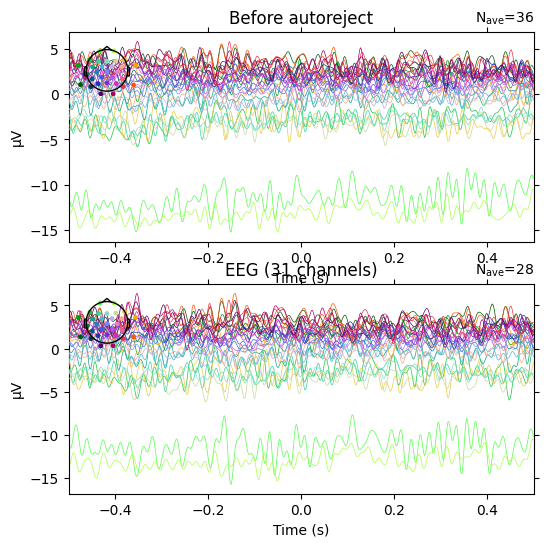

AutoReject completed.


<Figure size 640x480 with 0 Axes>

In [28]:
# Apply local AutoReject on the ICA-cleaned epochs
cleaned_epochs_AR, dic_AR = prep.AR_local(
    cleaned_epochs_ICA,
    strategy="union",
    threshold=50.0,
    verbose=True
)
print('AutoReject completed.')

### Picking Preprocessed Epochs

After cleaning, we separate the preprocessed epochs for each participant for further analysis.

In [29]:
# Assign cleaned epochs to individual participant variables
preproc_S1 = cleaned_epochs_AR[0]
preproc_S2 = cleaned_epochs_AR[1]
print('Preprocessed epochs for both participants are ready.')
print(f'Final number of epochs: {len(preproc_S1)}')
print(f'Final number of channels: {len(preproc_S1.info["ch_names"])}')

Preprocessed epochs for both participants are ready.
Final number of epochs: 28
Final number of channels: 31


## Information Theory Analysis: Mutual Information

Here we compute the **Mutual Information (MI)** between the two participants. MI is a symmetric measure that quantifies the total amount of information shared between two signals, capturing both linear and non-linear dependencies.

**Key properties:**
- Symmetric: MI(X,Y) = MI(Y,X)
- Temporal domain (not frequency-specific)
- Non-parametric (no assumptions about signal distributions with Gaussian estimator)

In [30]:
# Compute Mutual Information (symmetric measure)
mi_matrix = analyses_it.compute_mi_gaussian(
    [preproc_S1, preproc_S2],
    epochs_average=True
)

# Extract number of channels
n_ch = len(preproc_S1.info['ch_names'])

# Extract inter-brain MI (connectivity between participants)
inter_brain_mi = mi_matrix[0, :n_ch, n_ch:]

# Z-score normalization for visualization
mi_normalized = (inter_brain_mi - np.mean(inter_brain_mi)) / np.std(inter_brain_mi)

print(f"MI matrix shape: {mi_matrix.shape}")
print(f"Mean inter-brain MI: {np.mean(inter_brain_mi):.4f} nats")
print(f"Std inter-brain MI: {np.std(inter_brain_mi):.4f} nats")

/Users/remyramadour/Workspace/PPSP/Sandbox/InformationTheory/PPSPIntegration/Implementation/hypyp/hypyp/analyses_it.py:84: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data1 = epochs[0].get_data()
/Users/remyramadour/Workspace/PPSP/Sandbox/InformationTheory/PPSPIntegration/Implementation/hypyp/hypyp/analyses_it.py:85: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data2 = epochs[1].get_data()


MI matrix shape: (1, 62, 62)
Mean inter-brain MI: 0.0003 nats
Std inter-brain MI: 0.0004 nats


### Visualize MI Matrix

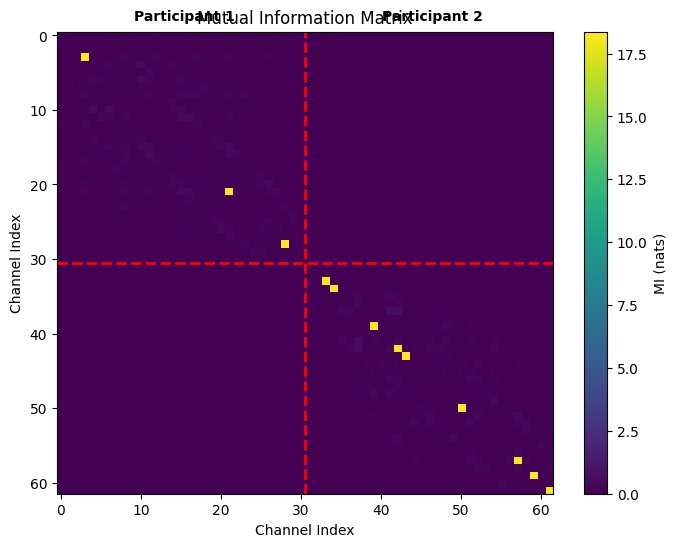

Note: The matrix is symmetric. Upper-right and lower-left blocks show inter-brain MI.


In [31]:
# Plot MI matrix as heatmap
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(mi_matrix[0], cmap='viridis', aspect='auto')
ax.set_title('Mutual Information Matrix')
ax.set_xlabel('Channel Index')
ax.set_ylabel('Channel Index')
ax.axhline(y=n_ch-0.5, color='red', linestyle='--', linewidth=2)
ax.axvline(x=n_ch-0.5, color='red', linestyle='--', linewidth=2)
ax.text(n_ch/2, -2, 'Participant 1', ha='center', fontweight='bold')
ax.text(3*n_ch/2, -2, 'Participant 2', ha='center', fontweight='bold')
plt.colorbar(im, ax=ax, label='MI (nats)')
plt.show()

print("Note: The matrix is symmetric. Upper-right and lower-left blocks show inter-brain MI.")

## Information Theory Analysis: Transfer Entropy

Now we compute **Transfer Entropy (TE)**, which measures the directional information flow from one participant to another. Unlike MI, TE is asymmetric and can reveal leader-follower dynamics.

**Key properties:**
- Asymmetric: TE(X→Y) ≠ TE(Y→X)
- Temporal domain with explicit time delay
- Sensitive to causal relationships

We will compute TE with multiple delays to explore temporal dynamics.

In [32]:
# Compute TE with different delays
# Delays in samples (at 250Hz: 1 sample ≈ 4ms, 5 samples ≈ 20ms, 10 samples ≈ 40ms)
delays = [1, 5, 10]

te_results = {}
for delay in delays:
    te_matrix = analyses_it.compute_te_gaussian(
        [preproc_S1, preproc_S2],
        delay=delay,
        epochs_average=True
    )
    te_results[delay] = te_matrix
    print(f"Computed TE with delay={delay} samples ({delay/sampling_rate*1000:.1f} ms)")

# Use delay=5 for detailed analysis
te_matrix = te_results[5]

# Extract inter-brain TE
te_1to2 = te_matrix[0, n_ch:, :n_ch]  # P1 → P2
te_2to1 = te_matrix[0, :n_ch, n_ch:]  # P2 → P1

# Compute asymmetry
te_asymmetry = te_1to2 - te_2to1

print(f"\nTE (P1→P2) mean: {np.mean(te_1to2):.4f} nats")
print(f"TE (P2→P1) mean: {np.mean(te_2to1):.4f} nats")
print(f"Asymmetry ratio: {np.mean(te_1to2) / (np.mean(te_2to1) + 1e-10):.2f}")

/Users/remyramadour/Workspace/PPSP/Sandbox/InformationTheory/PPSPIntegration/Implementation/hypyp/hypyp/analyses_it.py:216: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data1 = epochs[0].get_data()
/Users/remyramadour/Workspace/PPSP/Sandbox/InformationTheory/PPSPIntegration/Implementation/hypyp/hypyp/analyses_it.py:217: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data2 = epochs[1].get_data()


Computed TE with delay=1 samples (2.0 ms)


/Users/remyramadour/Workspace/PPSP/Sandbox/InformationTheory/PPSPIntegration/Implementation/hypyp/hypyp/analyses_it.py:216: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data1 = epochs[0].get_data()
/Users/remyramadour/Workspace/PPSP/Sandbox/InformationTheory/PPSPIntegration/Implementation/hypyp/hypyp/analyses_it.py:217: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data2 = epochs[1].get_data()


Computed TE with delay=5 samples (10.0 ms)


/Users/remyramadour/Workspace/PPSP/Sandbox/InformationTheory/PPSPIntegration/Implementation/hypyp/hypyp/analyses_it.py:216: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data1 = epochs[0].get_data()
/Users/remyramadour/Workspace/PPSP/Sandbox/InformationTheory/PPSPIntegration/Implementation/hypyp/hypyp/analyses_it.py:217: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data2 = epochs[1].get_data()


Computed TE with delay=10 samples (20.0 ms)

TE (P1→P2) mean: 0.0002 nats
TE (P2→P1) mean: 0.0002 nats
Asymmetry ratio: 0.99


### Visualize TE Asymmetry

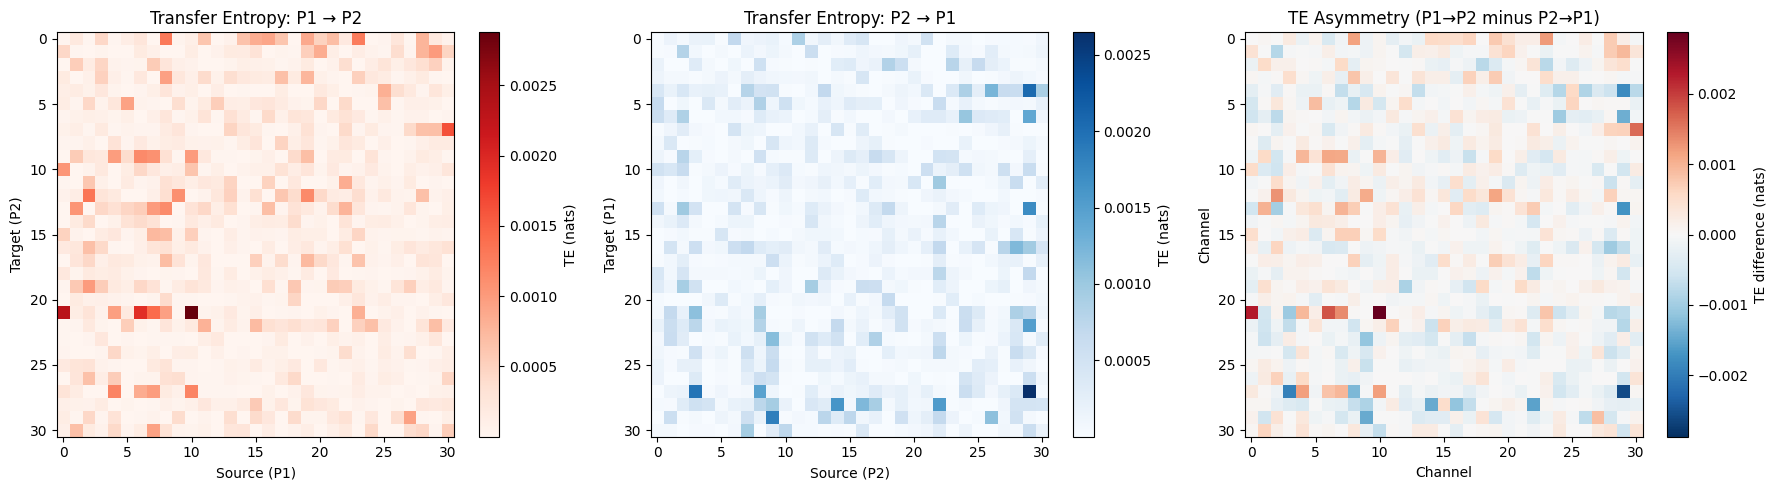

Red values indicate P1 leads, blue values indicate P2 leads.


In [33]:
# Plot TE in both directions and asymmetry
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# TE 1→2
im1 = axes[0].imshow(te_1to2, cmap='Reds', aspect='auto')
axes[0].set_title('Transfer Entropy: P1 → P2')
axes[0].set_xlabel('Source (P1)')
axes[0].set_ylabel('Target (P2)')
plt.colorbar(im1, ax=axes[0], label='TE (nats)')

# TE 2→1
im2 = axes[1].imshow(te_2to1, cmap='Blues', aspect='auto')
axes[1].set_title('Transfer Entropy: P2 → P1')
axes[1].set_xlabel('Source (P2)')
axes[1].set_ylabel('Target (P1)')
plt.colorbar(im2, ax=axes[1], label='TE (nats)')

# Asymmetry
im3 = axes[2].imshow(te_asymmetry, cmap='RdBu_r', aspect='auto', vmin=-np.max(np.abs(te_asymmetry)), vmax=np.max(np.abs(te_asymmetry)))
axes[2].set_title('TE Asymmetry (P1→P2 minus P2→P1)')
axes[2].set_xlabel('Channel')
axes[2].set_ylabel('Channel')
plt.colorbar(im3, ax=axes[2], label='TE difference (nats)')

plt.tight_layout()
plt.show()

print("Red values indicate P1 leads, blue values indicate P2 leads.")

### TE with Different Delays

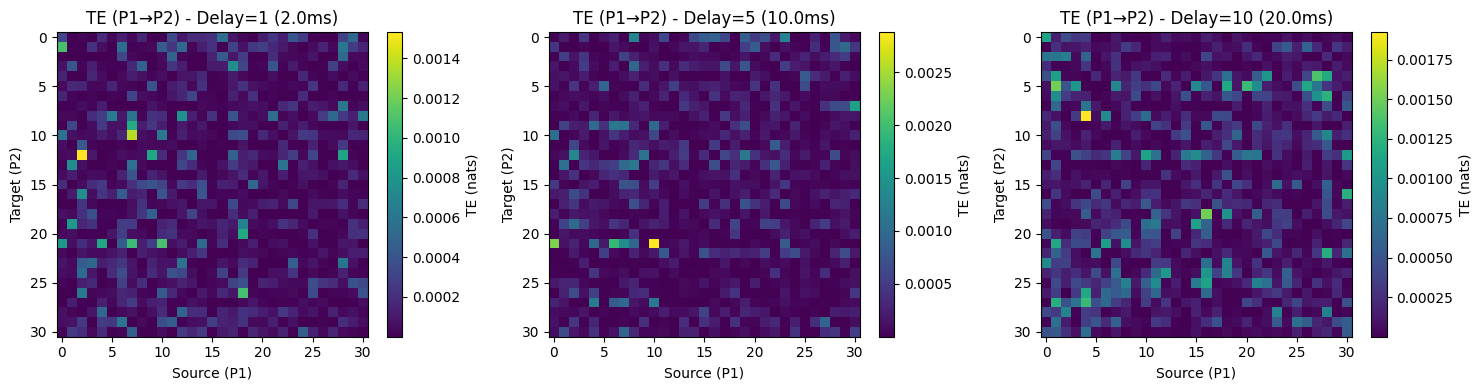

Note: Different delays capture different temporal dynamics.
The optimal delay depends on the timescale of neural coupling.


In [34]:
# Compare TE across different delays
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, delay in enumerate(delays):
    te = te_results[delay]
    te_inter = te[0, n_ch:, :n_ch]  # P1→P2
    
    im = axes[i].imshow(te_inter, cmap='viridis', aspect='auto')
    axes[i].set_title(f'TE (P1→P2) - Delay={delay} ({delay/sampling_rate*1000:.1f}ms)')
    axes[i].set_xlabel('Source (P1)')
    axes[i].set_ylabel('Target (P2)')
    plt.colorbar(im, ax=axes[i], label='TE (nats)')

plt.tight_layout()
plt.show()

print("Note: Different delays capture different temporal dynamics.")
print("The optimal delay depends on the timescale of neural coupling.")

## Comparison with Traditional Metrics

Let's compare MI/TE (temporal-domain, non-linear) with traditional frequency-domain metrics like Phase Locking Value (PLV).

In [35]:
# Compute PLV (Phase Locking Value) in Alpha band for comparison
complex_signal = analyses.compute_freq_bands(
    np.array([preproc_S1, preproc_S2]),
    sampling_rate,
    freq_bands,
    filter_length='auto',
    l_trans_bandwidth='auto',
    h_trans_bandwidth='auto'
)

plv_matrix = analyses.compute_sync(complex_signal, mode='plv', epochs_average=True)
plv_inter = plv_matrix[0, :n_ch, n_ch:]  # Inter-brain PLV

print("\nComparison: MI (temporal) vs PLV (alpha band):")
print(f"Mean MI: {np.mean(inter_brain_mi):.4f} nats")
print(f"Mean PLV: {np.mean(plv_inter):.4f}")
print(f"\nCorrelation between MI and PLV: {np.corrcoef(inter_brain_mi.flatten(), plv_inter.flatten())[0,1]:.3f}")

/Users/remyramadour/Workspace/PPSP/Sandbox/InformationTheory/PPSPIntegration/Implementation/hypyp/hypyp/analyses.py:854: RuntimeWarning: filter_length (825) is longer than the signal (501), distortion is likely. Reduce filter length or filter a longer signal.
  filtered = np.array([mne.filter.filter_data(data[participant],
/Users/remyramadour/Workspace/PPSP/Sandbox/InformationTheory/PPSPIntegration/Implementation/hypyp/hypyp/analyses.py:854: RuntimeWarning: filter_length (825) is longer than the signal (501), distortion is likely. Reduce filter length or filter a longer signal.
  filtered = np.array([mne.filter.filter_data(data[participant],



Comparison: MI (temporal) vs PLV (alpha band):
Mean MI: 0.0003 nats
Mean PLV: 0.2871

Correlation between MI and PLV: -0.004


### Side-by-side Comparison

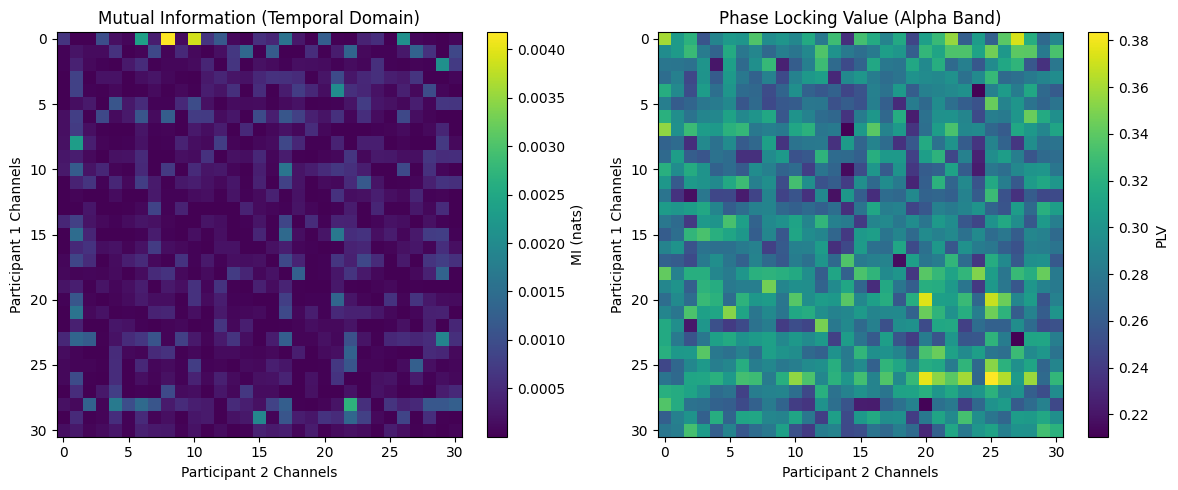

In [36]:
# Plot MI vs PLV side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# MI
im1 = axes[0].imshow(inter_brain_mi, cmap='viridis', aspect='auto')
axes[0].set_title('Mutual Information (Temporal Domain)')
axes[0].set_xlabel('Participant 2 Channels')
axes[0].set_ylabel('Participant 1 Channels')
plt.colorbar(im1, ax=axes[0], label='MI (nats)')

# PLV
im2 = axes[1].imshow(plv_inter, cmap='viridis', aspect='auto')
axes[1].set_title('Phase Locking Value (Alpha Band)')
axes[1].set_xlabel('Participant 2 Channels')
axes[1].set_ylabel('Participant 1 Channels')
plt.colorbar(im2, ax=axes[1], label='PLV')

plt.tight_layout()
plt.show()

## Visualization Using HyPyP Functions

HyPyP provides specialized visualization functions for inter-brain connectivity. Let's use them to visualize MI on 2D topomaps and 3D head models.

### 2D Topomap Visualization

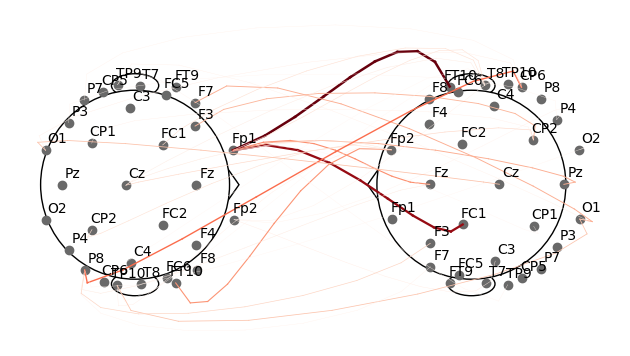

2D visualization of inter-brain MI connectivity


In [37]:
# Visualize MI as inter-brain connectivity on 2D topomap
# Note: HyPyP expects normalized connectivity values

viz.viz_2D_topomap_inter(
    preproc_S1,
    preproc_S2,
    mi_normalized,
    threshold='auto',
    steps=10,
    lab=True
)

print("2D visualization of inter-brain MI connectivity")

### 3D Head Model Visualization

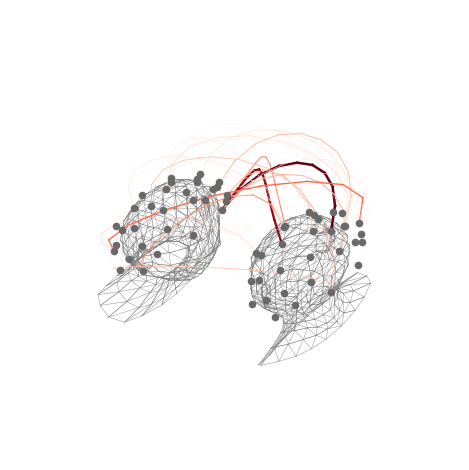

3D visualization of inter-brain MI connectivity


In [38]:
# Visualize MI on 3D head models
viz.viz_3D_inter(
    preproc_S1,
    preproc_S2,
    mi_normalized,
    threshold='auto',
    steps=10,
    lab=False
)

print("3D visualization of inter-brain MI connectivity")

## Interpretation and Discussion

### Mutual Information
- **Definition**: MI measures the total amount of information shared between two signals
- **Symmetric**: MI(X,Y) = MI(Y,X) - no directionality
- **Domain**: Temporal (broadband, not frequency-specific)
- **Captures**: Both linear and non-linear dependencies
- **Use case**: When interested in overall coupling strength, complementary to coherence/PLV

### Transfer Entropy
- **Definition**: TE measures directional information flow from source to target
- **Asymmetric**: TE(X→Y) ≠ TE(Y→X) - reveals directionality
- **Domain**: Temporal with explicit time delay parameter
- **Captures**: Predictive relationships and causal dynamics
- **Use case**: When interested in leader-follower dynamics, complementary to PDC/Granger causality

### Comparison with Traditional Metrics

| Metric | Domain | Symmetry | Linearity | Use Case |
|--------|--------|----------|-----------|----------|
| **Coherence** | Frequency | Symmetric | Linear | Oscillatory coupling |
| **PLV** | Frequency | Symmetric | Phase only | Phase synchronization |
| **PDC** | Frequency | Asymmetric | Linear (Granger) | Frequency-domain causality |
| **MI** | Temporal | Symmetric | **Non-linear** | Total information sharing |
| **TE** | Temporal | Asymmetric | **Non-linear** | Information flow |

### Key Insights
1. **MI and PLV may correlate** if phase coupling drives information sharing
2. **TE is sensitive to delay parameter** - explore multiple delays
3. **MI and TE are complementary** - MI for overall coupling, TE for directionality
4. **Non-linear dependencies** - MI/TE can capture relationships that coherence/PLV miss

### Limitations
- **Gaussian estimator assumption**: May underestimate true MI/TE for non-Gaussian signals
- **Sample size**: Requires sufficient data for reliable estimation
- **Statistical testing**: Standard stats may need adaptation for information-theoretic measures

### Recommendations
1. Use MI alongside PLV/coherence for comprehensive connectivity analysis
2. Explore multiple TE delays to find optimal timescale
3. Compare TE with PDC to understand frequency vs temporal causality
4. Consider non-parametric estimators (future work) for highly non-Gaussian data

## Summary

In this notebook, we demonstrated:
- ✓ Computing Mutual Information (MI) for inter-brain connectivity
- ✓ Computing Transfer Entropy (TE) with multiple delays
- ✓ Comparing MI/TE with traditional metrics (PLV)
- ✓ Visualizing results using HyPyP's 2D and 3D functions
- ✓ Interpreting information-theoretic measures in hyperscanning context

These new tools complement HyPyP's existing frequency-domain metrics, providing temporal-domain, non-linear alternatives for analyzing inter-brain coupling.